# SMF 07 · Cluster SMF across redshift

Supporting comparison of the MACH SMF (z ≈ 0.09) with the cluster SMFs of van der Burg et al. (2018; z ≈ 0.6) and (2020; z ≈ 1.2), and with TNG300 haloes at the matching snapshots (93, 63, 45).

**Inputs**: `SMF_results/MACH_total_results_R200.npz`, `DATA/LITERATURE_TABLES/vanderBurg2018_ClusterField_SMF_data.txt`, `vanderBurg2020_ClusterField_SMF_data.txt`, `DATA/TNG300/` (not included)

**Output**: figures only

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [2]:
# =============================================================
# Prerequisites for 07_SMF_evolution plotting cells
#
# This cell must be run first. It loads all four data sources
# that the plotting cells reference:
#   df_smf_mach    – MACH stacked SMF within R200 (from .npz)
#   df_smf_vdb2018 – van der Burg+2018 cluster SMF (0.5 < z < 0.7)
#   df_smf_vdb2020 – van der Burg+2020 cluster SMF (1.0 < z < 1.4)
#   data_tng       – TNG300 stacked SMF dict, keyed by snapshot number
# =============================================================

# -------------------------------------------------------------
# 1. MACH stacked SMF within R200
#    Source: .npz produced by 02a_SMF_total_MACH_stacked.ipynb
# -------------------------------------------------------------
mach = np.load('./SMF_results/MACH_total_results_R200.npz', allow_pickle=True)

_bin_centers  = mach['bin_centers']
_bin_width    = float(_bin_centers[1] - _bin_centers[0])
_mean_all     = mach['mean_all']

SMF_complimit = float(mach['complim'])

# Convert counts → number density  Φ(M)  [dex⁻¹ cluster⁻¹]
# Simple Poisson error: σ = √N / Δlog M
df_smf_mach = pd.DataFrame({
    'bin_center':                 _bin_centers,
    'x_log10_M':                  _bin_centers,          # alias kept for legacy code
    'phi_per_dex_per_cluster':    _mean_all / _bin_width,
    'phi_err_per_dex_per_cluster': np.sqrt(_mean_all) / _bin_width,
})

# -------------------------------------------------------------
# 2. van der Burg+2018 cluster SMF  (z ≈ 0.5–0.7)
#    SMF within R < 1.5 R500 is derived by subtracting the
#    outer shell (1.5 R500 – 2 R500) from the total (< 2 R500).
# -------------------------------------------------------------
df_smf_vdb2018 = pd.read_csv(
    f'{MAINPATH}/DATA/LITERATURE_TABLES/vanderBurg2018_ClusterField_SMF_data.txt',
    skiprows=16
).fillna(0)

# Inner SMF = total within 2R500 minus outer shell
df_smf_vdb2018['Phi_cluster_to_1p5R500'] = (
    df_smf_vdb2018['Phi_cluster_to_2R500']
    - df_smf_vdb2018['Phi_cluster_1p5R500_to_2R500']
)

# Propagate statistical and systematic errors in quadrature (upper)
df_smf_vdb2018['Phi_cluster_to_1p5R500_err_plus'] = np.sqrt(
    df_smf_vdb2018['Phi_cluster_to_2R500_stat_plus']**2 +
    df_smf_vdb2018['Phi_cluster_to_2R500_sys_plus']**2 +
    df_smf_vdb2018['Phi_cluster_1p5R500_to_2R500_stat_plus']**2 +
    df_smf_vdb2018['Phi_cluster_1p5R500_to_2R500_sys_plus']**2
)

# Propagate statistical and systematic errors in quadrature (lower)
df_smf_vdb2018['Phi_cluster_to_1p5R500_err_minus'] = np.sqrt(
    df_smf_vdb2018['Phi_cluster_to_2R500_stat_minus']**2 +
    df_smf_vdb2018['Phi_cluster_to_2R500_sys_minus']**2 +
    df_smf_vdb2018['Phi_cluster_1p5R500_to_2R500_stat_minus']**2 +
    df_smf_vdb2018['Phi_cluster_1p5R500_to_2R500_sys_minus']**2
)

# -------------------------------------------------------------
# 3. van der Burg+2020 cluster SMF  (z ≈ 1.0–1.4)
#    Pre-processed table; assumed ready to use as-is.
# -------------------------------------------------------------
df_smf_vdb2020 = pd.read_csv(
    f'{MAINPATH}/DATA/LITERATURE_TABLES/vanderBurg2020_ClusterField_SMF_data.txt'
)

# -------------------------------------------------------------
# 4. TNG300 stacked SMFs for snapshots 45, 63, 93
#    Per-snapshot halo-mass cuts and radius definitions
#    are chosen to approximate the observational comparison samples:
#      snap 93  (z≈0.07) : M200c > 5×10¹⁴ M☉,  within R200
#      snap 63  (z≈0.60) : M200c > 4×10¹⁴ M☉,  within 1.5 R500
#      snap 45  (z≈1.52) : M200c > 1×10¹⁴ M☉,  within R200
#    (snap 45 uses a lower mass cut because very few haloes exceed
#     5×10¹⁴ M☉ at z>1; the cut is adjusted to match the number
#     of clusters in vdB+2020.)
# -------------------------------------------------------------
cosmo_h = 0.6774    # TNG Hubble constant

bin_min, bin_max, bin_width_tng = 7, 13, 0.25
bins_tng    = np.arange(bin_min, bin_max + bin_width_tng, bin_width_tng)
bc_tng      = bins_tng[:-1] + bin_width_tng / 2

snap_config = {
    93: {"mass_cut": 5e14, "r_key": "Group_R_Crit200", "r_mult": 1.0},
    63: {"mass_cut": 4e14, "r_key": "Group_R_Crit500", "r_mult": 1.5},
    45: {"mass_cut": 1e14, "r_key": "Group_R_Crit200", "r_mult": 1.0},
}

data_tng = {}

for snap, cfg in snap_config.items():
    hist_list = []

    haloinfo_path = (
        f'{MAINPATH}/DATA/TNG300/'
        f'TNG300_output_snapNum_{snap}/'
        f'Massive_Haloinfo_SnapNum{snap}.csv'
    )
    try:
        haloinfo = pd.read_csv(haloinfo_path)
    except FileNotFoundError:
        print(f"[TNG snap {snap}] haloinfo not found: {haloinfo_path}")
        data_tng[snap] = {"x": np.array([]), "y": np.array([]),
                          "yerr_lo": np.array([]), "yerr_up": np.array([])}
        continue

    # Apply halo mass cut  (Group_M_Crit200 is stored in 10^10 M☉ / h)
    massive = haloinfo[
        haloinfo['Group_M_Crit200'] * 1e10 / cosmo_h > cfg["mass_cut"]
    ]
    print(f"[TNG snap {snap}]  {len(massive)} haloes selected "
          f"(M200c > {cfg['mass_cut']:.0e} M☉)")

    for hid in massive["HaloIndex"].values:
        fpath = (
            f'{MAINPATH}/DATA/TNG300/'
            f'TNG300_output_snapNum_{snap}/HALOCAT/'
            f'halo{hid:08d}_result.csv'
        )
        try:
            df_halo = pd.read_csv(fpath)
        except FileNotFoundError:
            continue

        # Convert R_crit from kpc/h → comoving Mpc and apply multiplier
        R_kpc  = massive.loc[massive["HaloIndex"] == hid, cfg["r_key"]].iloc[0]
        R_cmpc = R_kpc * 1e-3 / cosmo_h
        R_sel  = cfg["r_mult"] * R_cmpc

        sel = df_halo[df_halo["Distance (cMpc)"] < R_sel]
        if sel.empty:
            continue

        logm = np.log10(sel["StellarMass (Msol)"])
        counts, _ = np.histogram(logm, bins=bins_tng)
        hist_list.append(counts / bin_width_tng)

    if hist_list:
        H         = np.vstack(hist_list)
        mean_h    = H.mean(axis=0)
        stderr    = H.std(axis=0, ddof=1) / np.sqrt(H.shape[0])
        valid     = mean_h > 0
        data_tng[snap] = {
            "x":       bc_tng[valid],
            "y":       mean_h[valid],
            "yerr_lo": stderr[valid],
            "yerr_up": stderr[valid],
        }
    else:
        print(f"[TNG snap {snap}]  No valid histograms – check HALOCAT files.")
        data_tng[snap] = {"x": np.array([]), "y": np.array([]),
                          "yerr_lo": np.array([]), "yerr_up": np.array([])}

print("\nAll data sources ready:")
print(f"  df_smf_mach    : {len(df_smf_mach)} bins, complimit = {SMF_complimit}")
print(f"  df_smf_vdb2018 : {len(df_smf_vdb2018)} bins")
print(f"  df_smf_vdb2020 : {len(df_smf_vdb2020)} bins")
for snap in (45, 63, 93):
    n = len(data_tng[snap]["x"])
    print(f"  data_tng[{snap}]   : {n} valid bins")

[TNG snap 93]  9 haloes selected (M200c > 5e+14 M☉)
[TNG snap 63]  9 haloes selected (M200c > 4e+14 M☉)
[TNG snap 45]  32 haloes selected (M200c > 1e+14 M☉)


/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inp


All data sources ready:
  df_smf_mach    : 30 bins, complimit = 9.0
  df_smf_vdb2018 : 23 bins
  df_smf_vdb2020 : 23 bins
  data_tng[45]   : 22 valid bins
  data_tng[63]   : 23 valid bins
  data_tng[93]   : 23 valid bins


/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inp

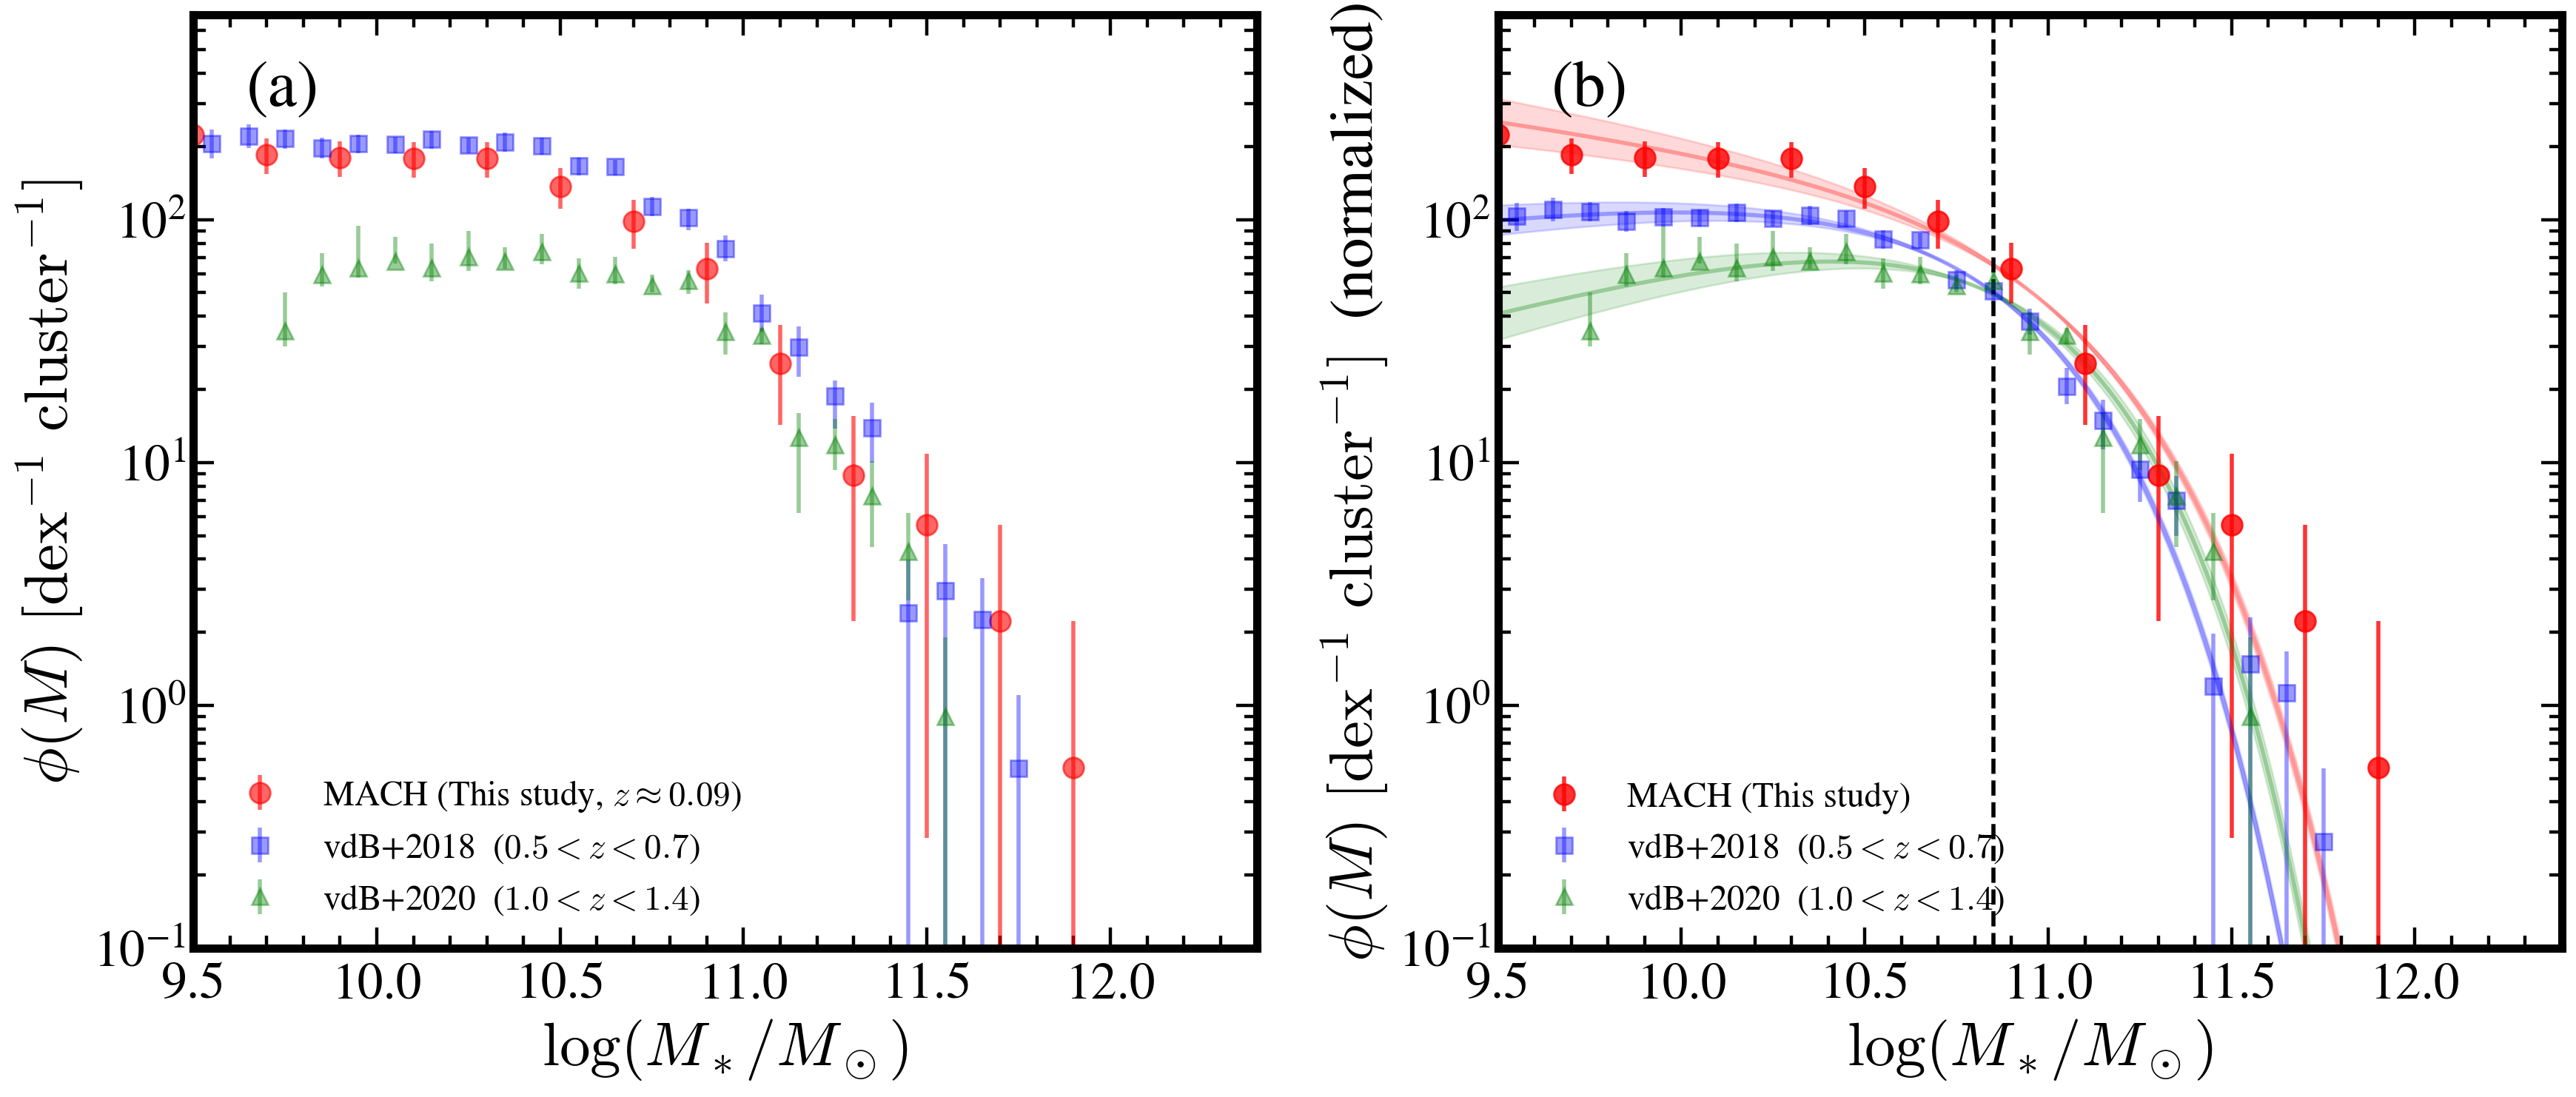

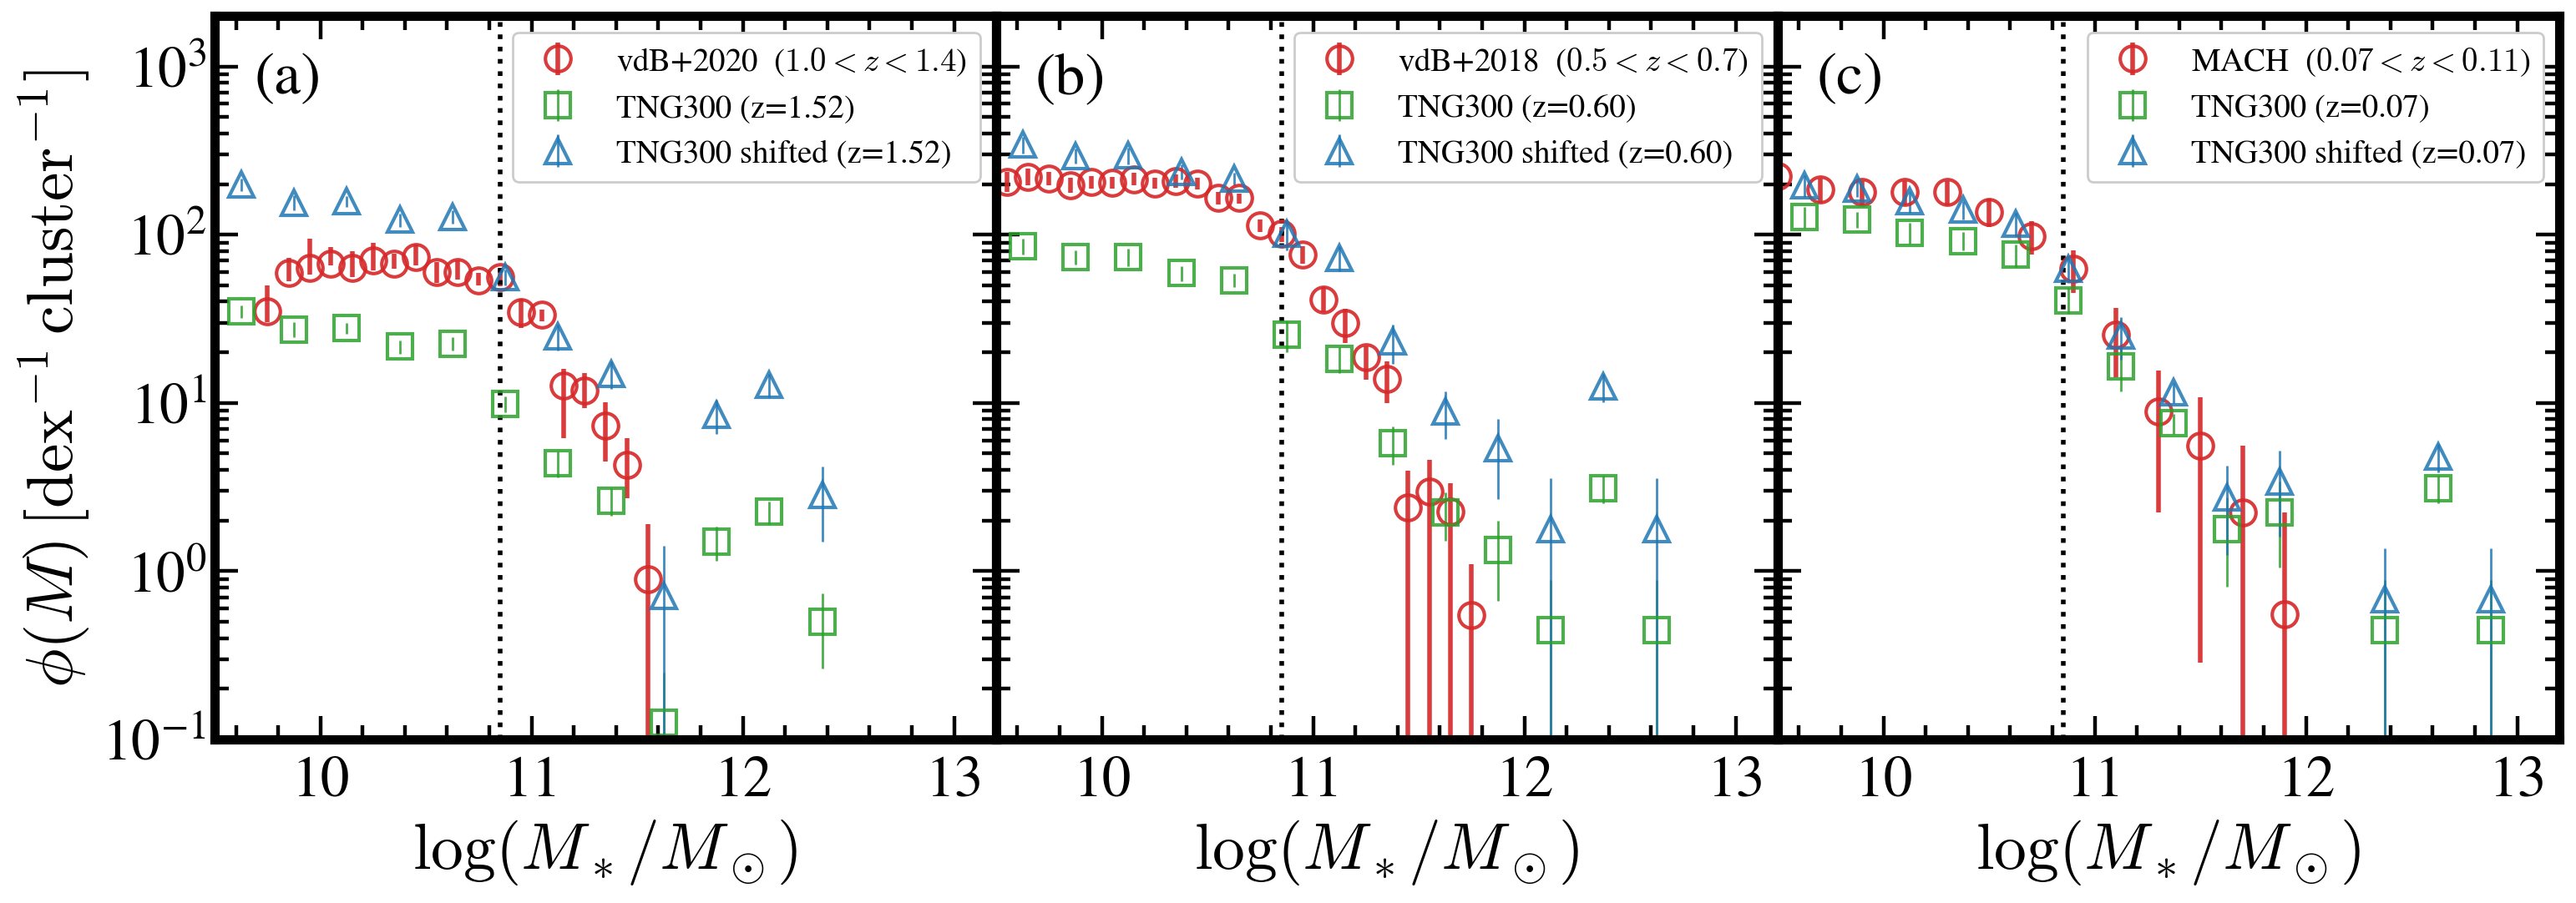

In [3]:
from scipy.optimize import curve_fit

# =============================================================
# Uses the following from the cell above:
#   df_smf_mach     – MACH stacked SMF DataFrame (from .npz loader)
#   df_smf_vdb2018  – van der Burg+2018 cluster SMF
#   df_smf_vdb2020  – van der Burg+2020 cluster SMF
#   data_tng        – dict[snap] with TNG SMF arrays (x, y, yerr_lo, yerr_up)
# =============================================================

# =============================================================
# Schechter function and curve-fit helper
# =============================================================
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

def fit_and_plot_schechter(ax, x, y, yerr, color,
                           p0=None, line_alpha=1.0, shade_alpha=0.15):
    """
    Fit a Schechter function to (x, y ± yerr) and draw the best-fit
    curve with a ±1σ_alpha shaded band on ax.

    p0   : initial guess [phi_0, M_star, alpha]
    shade: alpha error propagated shading around the best-fit line
    """
    if p0 is None:
        p0 = [100, 10.7, -1.0]

    bounds = ([1e-3, 10.0, -2.5], [1e5, 11.5, -0.2])

    # Fit only over the reliable mass range
    mask = (x >= 9.0) & (x <= 12.0) & np.isfinite(y) & np.isfinite(yerr)
    popt, pcov = curve_fit(
        schechter_1D_SMF, x[mask], y[mask], sigma=yerr[mask],
        absolute_sigma=True, p0=p0, bounds=bounds
    )
    phi_0_fit, M_star_fit, alpha_fit = popt
    alpha_err = np.sqrt(np.diag(pcov))[2]

    M_model = np.linspace(9.5, 12.0, 300)
    y_mid  = schechter_1D_SMF(M_model, phi_0_fit, M_star_fit, alpha_fit)
    y_low  = schechter_1D_SMF(M_model, phi_0_fit, M_star_fit, alpha_fit - alpha_err)
    y_high = schechter_1D_SMF(M_model, phi_0_fit, M_star_fit, alpha_fit + alpha_err)

    ax.plot(M_model, y_mid, color=color, lw=2, alpha=line_alpha)
    ax.fill_between(M_model, y_low, y_high, color=color, alpha=shade_alpha)

# =============================================================
# Helper: find index of array element closest to a reference value
# =============================================================
def _nearest_idx(arr, ref):
    arr = np.asarray(arr)
    return None if arr.size == 0 else np.argmin(np.abs(arr - ref))

# =============================================================
# Common plot settings
# =============================================================
ref_mass = 10.85     # reference mass used for normalization anchor

# Normalization scale factors applied to each dataset
# (set to 1.0 for raw; adjust the "norm" versions for shape comparison)
factor = {
    'mach_raw':   1.0,
    'vdb2018_raw': 1.0,
    'vdb2020_raw': 1.0,
    'mach_norm':   1.0,
    'vdb2018_norm': 1.0 / 2.0,
    'vdb2020_norm': 1.0 / 1.0,
}

# Pull MACH arrays out once so they can be reused across panels
x_mach    = df_smf_mach['bin_center'].to_numpy()
y_mach    = df_smf_mach['phi_per_dex_per_cluster'].to_numpy()
yerr_mach = df_smf_mach['phi_err_per_dex_per_cluster'].to_numpy()
mask_mach = np.isfinite(x_mach) & np.isfinite(y_mach) & np.isfinite(yerr_mach)

# vdB+2018 arrays
x_18    = df_smf_vdb2018['logM'].to_numpy()
y_18    = df_smf_vdb2018['Phi_cluster_to_1p5R500'].to_numpy()
yerr_18_lo = df_smf_vdb2018['Phi_cluster_to_1p5R500_err_minus'].to_numpy()
yerr_18_hi = df_smf_vdb2018['Phi_cluster_to_1p5R500_err_plus'].to_numpy()
yerr_18_sym = 0.5 * (yerr_18_lo + yerr_18_hi)
mask_18 = np.isfinite(x_18) & np.isfinite(y_18) & np.isfinite(yerr_18_sym)

# vdB+2020 arrays
x_20    = df_smf_vdb2020['logMstar'].to_numpy()
y_20    = df_smf_vdb2020['Cluster1000kpc_All'].to_numpy()
yerr_20_lo = df_smf_vdb2020['All_err_low'].to_numpy()
yerr_20_hi = df_smf_vdb2020['All_err_high'].to_numpy()
yerr_20_sym = 0.5 * (yerr_20_lo + yerr_20_hi)
mask_20 = np.isfinite(x_20) & np.isfinite(y_20) & np.isfinite(yerr_20_sym)

# =============================================================
# Figure 1 (1 × 2): raw comparison  |  normalized + Schechter fits
# =============================================================
fig, axs = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# ------------------------------------------------------------------
# Panel (a) – Raw SMF comparison across redshift (data points only)
# ------------------------------------------------------------------
ax = axs[0]

ax.errorbar(
    x_mach[mask_mach], y_mach[mask_mach] * factor['mach_raw'],
    yerr=yerr_mach[mask_mach] * factor['mach_raw'],
    fmt='o', ms=10, color='red', alpha=0.6, capsize=0,
    label='MACH (This study, $z\\approx0.09$)'
)
ax.errorbar(
    x_18[mask_18], y_18[mask_18] * factor['vdb2018_raw'],
    yerr=[yerr_18_lo[mask_18] * factor['vdb2018_raw'],
          yerr_18_hi[mask_18] * factor['vdb2018_raw']],
    fmt='s', ms=8, color='blue', alpha=0.4, capsize=0,
    label=r'vdB+2018  ($0.5 < z < 0.7$)'
)
ax.errorbar(
    x_20[mask_20], y_20[mask_20] * factor['vdb2020_raw'],
    yerr=[yerr_20_lo[mask_20] * factor['vdb2020_raw'],
          yerr_20_hi[mask_20] * factor['vdb2020_raw']],
    fmt='^', ms=8, color='green', alpha=0.4, capsize=0,
    label=r'vdB+2020  ($1.0 < z < 1.4$)'
)

ax.set_yscale('log')
ax.set_xlim(9.5, 12.4)
ax.set_ylim(0.1, 700)
ax.set_xticks(np.arange(9.5, 12.5, 0.5))
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=30)
ax.set_ylabel(r'$\phi(M)\ [\mathrm{dex}^{-1}\ \mathrm{cluster}^{-1}]$', fontsize=30)
ax.legend(fontsize=17, loc='lower left', frameon=False)
ax.text(0.05, 0.95, '(a)', transform=ax.transAxes,
        fontsize=32, va='top', ha='left')

# ------------------------------------------------------------------
# Panel (b) – Normalized SMF + Schechter fits (shape comparison)
#   Each dataset is rescaled so the SMFs can be compared by shape
#   independent of the absolute normalisation difference.
# ------------------------------------------------------------------
ax = axs[1]

# MACH
y_m = y_mach[mask_mach] * factor['mach_norm']
ye_m = yerr_mach[mask_mach] * factor['mach_norm']
ax.errorbar(x_mach[mask_mach], y_m, yerr=ye_m,
            fmt='o', ms=10, color='red', alpha=0.8, capsize=0,
            label='MACH (This study)')
fit_and_plot_schechter(ax, x_mach[mask_mach], y_m, ye_m,
                       color='red', p0=[1.0, 10.6, -1.1], line_alpha=0.3)

# vdB+2018
y_18n = y_18[mask_18] * factor['vdb2018_norm']
ye_18n_lo = yerr_18_lo[mask_18] * factor['vdb2018_norm']
ye_18n_hi = yerr_18_hi[mask_18] * factor['vdb2018_norm']
ye_18n_sym = 0.5 * (ye_18n_lo + ye_18n_hi)
ax.errorbar(x_18[mask_18], y_18n, yerr=[ye_18n_lo, ye_18n_hi],
            fmt='s', ms=8, color='blue', alpha=0.4, capsize=0,
            label=r'vdB+2018  ($0.5 < z < 0.7$)')
fit_and_plot_schechter(ax, x_18[mask_18], y_18n, ye_18n_sym,
                       color='blue', line_alpha=0.3)

# vdB+2020
y_20n = y_20[mask_20] * factor['vdb2020_norm']
ye_20n_lo = yerr_20_lo[mask_20] * factor['vdb2020_norm']
ye_20n_hi = yerr_20_hi[mask_20] * factor['vdb2020_norm']
ye_20n_sym = 0.5 * (ye_20n_lo + ye_20n_hi)
ax.errorbar(x_20[mask_20], y_20n, yerr=[ye_20n_lo, ye_20n_hi],
            fmt='^', ms=8, color='green', alpha=0.4, capsize=0,
            label=r'vdB+2020  ($1.0 < z < 1.4$)')
fit_and_plot_schechter(ax, x_20[mask_20], y_20n, ye_20n_sym,
                       color='green', line_alpha=0.3)

# Vertical reference line marking the normalization anchor mass
ax.axvline(ref_mass, color='black', ls='--', lw=2)

ax.set_yscale('log')
ax.set_xlim(9.5, 12.4)
ax.set_ylim(0.1, 700)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=30)
ax.set_ylabel(r'$\phi(M)\ [\mathrm{dex}^{-1}\ \mathrm{cluster}^{-1}]$  (normalized)', fontsize=30)
ax.legend(fontsize=17, loc='lower left', frameon=False)
ax.yaxis.set_tick_params(labelleft=True)
ax.text(0.05, 0.95, '(b)', transform=ax.transAxes,
        fontsize=32, va='top', ha='left')

plt.tight_layout()
# plt.savefig(f'{FIGUREPATH}/SMF_evolution.pdf', bbox_inches='tight')
plt.show()

# =============================================================
# Figure 2 (1 × 3): obs SMF vs. TNG300 at each redshift
#   Panel order: (a) z~1.5  (b) z~0.6  (c) z~0.07
#
#   For each snapshot:
#     - red circles  = observed (vdB+2020 / vdB+2018 / MACH)
#     - green squares  = raw TNG SMF (as-computed, no shift)
#     - blue triangles = TNG SMF shifted to match obs at ref_mass
# =============================================================

# Bundle observational SMF per snapshot
obs_data = {
    45: dict(
        x     = x_20,
        y     = y_20,
        yerr_lo = yerr_20_lo,
        yerr_hi = yerr_20_hi,
        label = r"vdB+2020  ($1.0 < z < 1.4$)"
    ),
    63: dict(
        x     = x_18,
        y     = y_18,
        yerr_lo = yerr_18_lo,
        yerr_hi = yerr_18_hi,
        label = r"vdB+2018  ($0.5 < z < 0.7$)"
    ),
    93: dict(
        x     = x_mach,
        y     = y_mach,
        yerr_lo = yerr_mach,
        yerr_hi = yerr_mach,
        label = r"MACH  ($0.07 < z < 0.11$)"
    ),
}

# Compute per-snapshot normalization factor:
#   shift = φ_obs(ref_mass) / φ_TNG(ref_mass)
# so the shifted TNG curve passes through the observed value at ref_mass.
sim_norm = {}
for snap in (45, 63, 93):
    simx = np.asarray(data_tng[snap]["x"])
    simy = np.asarray(data_tng[snap]["y"])
    od   = obs_data[snap]

    idx_sim = _nearest_idx(simx, ref_mass)
    idx_obs = _nearest_idx(od["x"], ref_mass)

    if idx_sim is None or idx_obs is None:
        sim_norm[snap] = 1.0
    else:
        y_sim_at_ref = simy[idx_sim]
        y_obs_at_ref = od["y"][idx_obs]
        sim_norm[snap] = y_obs_at_ref / y_sim_at_ref if y_sim_at_ref > 0 else 1.0

# Style
COLOR   = {"obs": "tab:red", "raw": "tab:green", "shift": "tab:blue"}
MARK_RAW   = "s"
MARK_SHIFT = "^"
Z_LABELS   = {45: "z=1.52", 63: "z=0.60", 93: "z=0.07"}

fig, axes = plt.subplots(
    1, 3, figsize=(16, 6),
    sharex=True, sharey=True,
    gridspec_kw={'wspace': 0}
)

for ax, snap, panel_label in zip(axes, (45, 63, 93), ['(a)', '(b)', '(c)']):

    # --- Observed SMF ---
    od = obs_data[snap]
    ax.errorbar(
        od["x"], od["y"],
        yerr=[od["yerr_lo"], od["yerr_hi"]],
        fmt='o', ms=11, markeredgewidth=1.5,
        color=COLOR["obs"], ecolor=COLOR["obs"],
        markerfacecolor='none', alpha=0.9, capsize=0,
        label=od["label"]
    )

    # --- TNG raw and shifted SMFs ---
    d          = data_tng[snap]
    x_tng      = np.asarray(d["x"])
    y_tng      = np.asarray(d["y"])
    yerr_lo    = np.asarray(d["yerr_lo"])
    yerr_hi    = np.asarray(d["yerr_up"])

    if x_tng.size > 0:
        # Raw TNG
        ax.errorbar(
            x_tng, y_tng, yerr=[yerr_lo, yerr_hi],
            fmt=MARK_RAW, ms=11, markeredgewidth=1.5,
            color=COLOR["raw"], ecolor=COLOR["raw"],
            markerfacecolor='none', linewidth=1, capsize=0, alpha=0.85,
            label=f"TNG300 ({Z_LABELS[snap]})"
        )
        # Shifted TNG (multiplied by normalization factor)
        s = sim_norm[snap]
        ax.errorbar(
            x_tng, y_tng * s, yerr=[yerr_lo * s, yerr_hi * s],
            fmt=MARK_SHIFT, ms=11, markeredgewidth=1.5,
            color=COLOR["shift"], ecolor=COLOR["shift"],
            markerfacecolor='none', linewidth=1, capsize=0, alpha=0.85,
            label=f"TNG300 shifted ({Z_LABELS[snap]})"
        )

    # Vertical line at the normalization anchor mass
    ax.axvline(ref_mass, color='black', ls=':', lw=2)

    ax.set_yscale('log')
    ax.set_xlim(9.5, 13.2)
    ax.set_ylim(0.1, 2000)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=28)
    ax.legend(loc='upper right', fontsize=14, frameon=True, framealpha=1)
    ax.text(0.05, 0.95, panel_label, transform=ax.transAxes,
            fontsize=26, va='top', ha='left')

axes[0].set_ylabel(
    r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$',
    fontsize=28
)

plt.tight_layout()
# plt.savefig(f'{FIGUREPATH}/SMF_evolution_sub.pdf', bbox_inches='tight')
plt.show()